In [1]:
import torch
from deepinv.physics import MRI, GaussianNoise
from deepinv.physics.generator import GaussianMaskGenerator
from deepinv.datasets import FastMRISliceDataset
from deepinv.utils import plot
from deepinv.sampling import DPSDataFidelity, PosteriorDiffusion, EulerSolver, VarianceExplodingDiffusion, DiffPIR, DPS
from deepinv.optim.data_fidelity import L2
from deepinv.loss.metric import LPIPS, PSNR
device = torch.device("cuda")
seed = 42

In [2]:
def normalize(x):
    "Project x in the [0, 1] range."
    flatx = x.view(x.shape[0], -1)
    minval, maxval = torch.min(flatx, dim=1).values, torch.max(flatx, dim=1).values
    return (x - minval[:, None, None, None])/(maxval - minval)[:, None, None, None]


In [3]:
# load a random mask
img_size = 320
R = 6  # acceleration factor
mask_gen = GaussianMaskGenerator(acceleration=R, img_size=(img_size,img_size))
mask = mask_gen.step()["mask"].to(device)

sigma = 0.1  # noise level

In [4]:
# create physics
physics = MRI(mask=mask, img_size=(320, 320), device=device, noise_model=GaussianNoise(sigma))

In [5]:
# load datasets
knee_ds = FastMRISliceDataset("datasets/mri/knee")
brain_ds = FastMRISliceDataset("datasets/mri/brain")
img_size = 320

100%|██████████| 114/114 [00:00<00:00, 447.60it/s]


In [6]:
# pull one sample from the dataset and generate measurements
x = torch.zeros([1, 2, 320, 320]).to(device)
x[0, 0] =  normalize(brain_ds[20][0])

y = physics(x)


In [7]:
denoiser = torch.load("models/diffusion/brain.pth", weights_only=False).to(device)

class InputWrapper(torch.nn.Module):  # wrapper class to use deepinv MRI 
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model.to(device)

    def forward(self, x, scalar):
        extra = 2*normalize(x[:, :1]) -1 # extract the real part
        respart = normalize(self.base_model(extra, 2*scalar))
        res = torch.zeros_like(x, device=extra.device)
        res[:, 0] = respart[:, 0]
        return res
        
denoiser = InputWrapper(denoiser)  

model = DiffPIR(data_fidelity=L2(),
                 model=denoiser, sigma=sigma,
                device=device, verbose=True, max_iter=500)
x_init = physics.A_adjoint(y)
x_rec = model(y=y, physics=physics, x_init=x_init, seed=0)


100%|██████████| 500/500 [01:09<00:00,  7.22it/s]


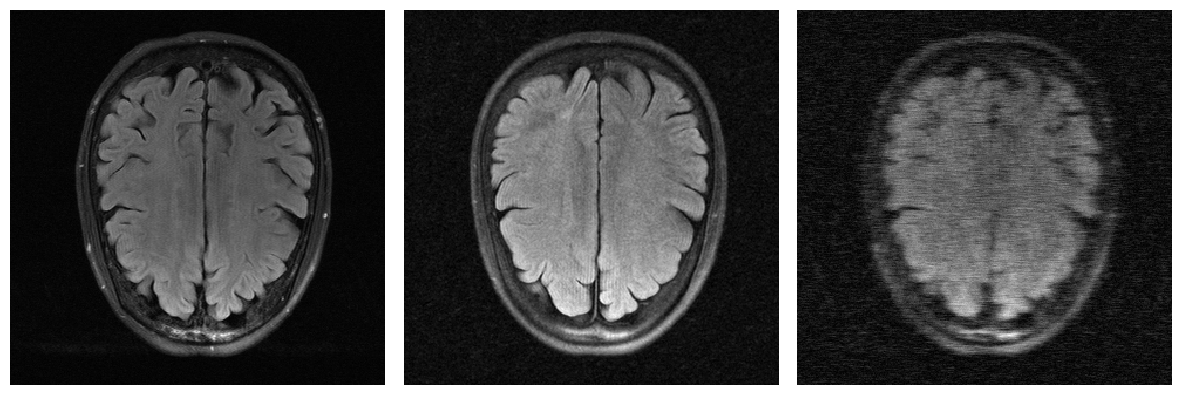

In [8]:
plot([x, x_rec,x_init], figsize=(15,5))